<a href="https://colab.research.google.com/github/a669-del/abhay-kumar/blob/main/credit_card001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection — Comprehensive Exploratory Data Analysis
Detecting Fraudulent Transactions Using Machine Learning and Data Analytics

# About This Notebook📘

Financial fraud is one of the biggest challenges in the digital banking era. Millions of online transactions occur every day, and even a tiny percentage of fraudulent activity can lead to massive financial losses.

This project performs a deep Exploratory Data Analysis (EDA) on credit card transaction data to uncover hidden fraud patterns, understand customer transaction behavior, and build machine learning models capable of identifying fraudulent transactions.

# Using this dataset, we will explore important analytical questions such as:

How rare are fraudulent transactions?

What transaction patterns indicate fraud?

Which features are most important in fraud detection?

How does transaction amount vary between fraud and genuine transactions?

Can Machine Learning accurately predict fraudulent activity?

# This notebook combines:

📊 Data Analysis

📈 Visualization

🧹 Data Cleaning

🤖 Machine Learning

📉 Fraud Pattern Detection

⚙️ Feature Engineering

to create a complete end-to-end Fraud Detection project.

# 📑 Table of Contents

1. 📘 Introduction
2. 📂 Dataset Collection
3. ⚙️ Environment Setup
4. 🔍 Data Loading and Inspection
5. 🧹 Data Cleaning
6. 📊 Exploratory Data Analysis (EDA)

   6.1 Fraud vs Genuine Transactions
   6.2 Transaction Amount Analysis
   6.3 Correlation Analysis
   6.4 Fraud Pattern Detection
   6.5 Time-Based Analysis
   6.6 Feature Distribution

7. ⚙️ Data Preprocessing
8. 🤖 Machine Learning Model
9. 📈 Model Evaluation
10. 🏆 Feature Importance
11. 📌 Conclusion

# Section 1 : Fetching Dataset by Kaggle.json

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)


# Extract ZIP File

In [ ]:
import zipfile

zip_path = "/content/creditcardfraud.zip"
extract_dir = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Section 2 : Environment Setup

In [ ]:
# Core Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Plot Configuration
FRAUD_RED   = '#D32F2F'
DARK_BLUE   = '#0D1B2A'
LIGHT_BLUE  = '#1B263B'

PALETTE = [FRAUD_RED, '#1976D2', '#388E3C', '#FBC02D']

plt.rcParams.update({
    'figure.dpi'         : 120,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.titlesize'     : 13,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 11,
    'font.family'        : 'serif',
    'figure.facecolor'   : 'white'
})

sns.set_style('whitegrid')

# Section 3 : Data Loading and Initial Inspection

In [ ]:
df = pd.read_csv("/content/creditcard.csv")

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 284807
Columns : 31


# Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# Statistical Summary

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# Section 4 : Data Cleaning

Missing Values

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Duplicate Values

In [ ]:
df.duplicated().sum()

np.int64(1081)

Remove Duplicate Rows

In [ ]:
df = df.drop_duplicates()

# **Section 5 : Exploratory Data Analysis (EDA)**

# 📊 5.1 Fraud vs Genuine Transactions

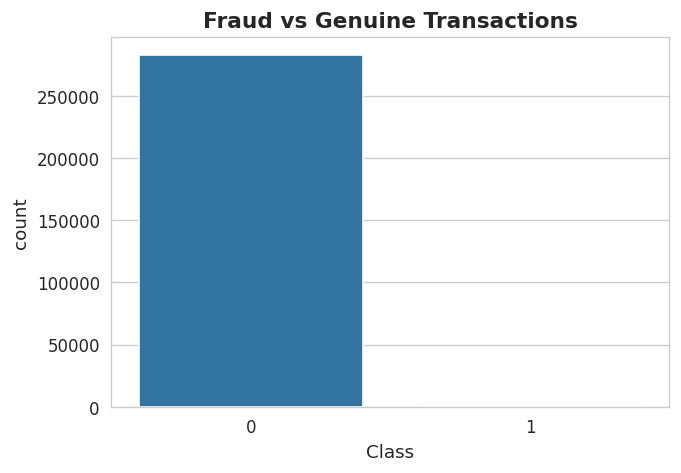

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title("Fraud vs Genuine Transactions")
plt.show()

# Fraud Percentage

In [ ]:
fraud_percentage = (df['Class'].value_counts()[1] / len(df)) * 100

print("Fraud Percentage :", fraud_percentage)

Fraud Percentage : 0.1667101358352777


# 💰 5.2 Transaction Amount Distribution

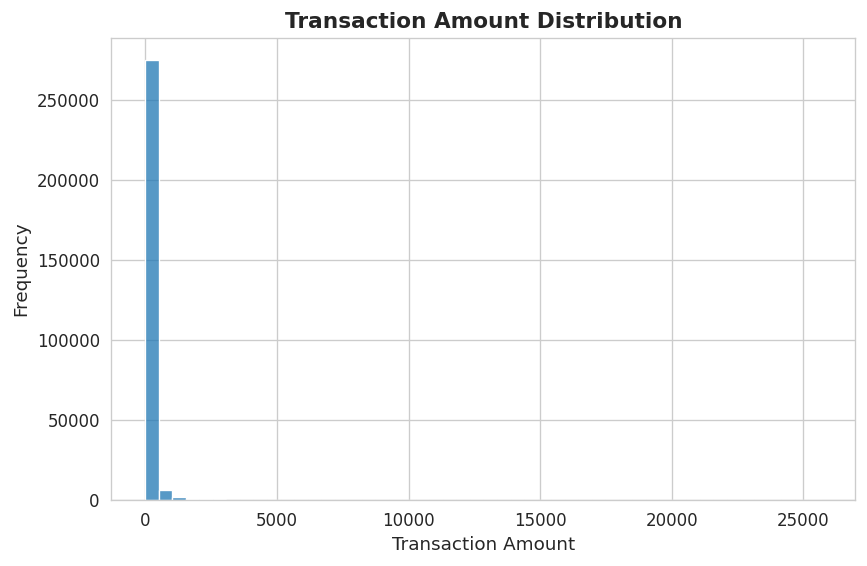

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Amount'], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

# 🔍 5.3 Fraud Transaction Amount

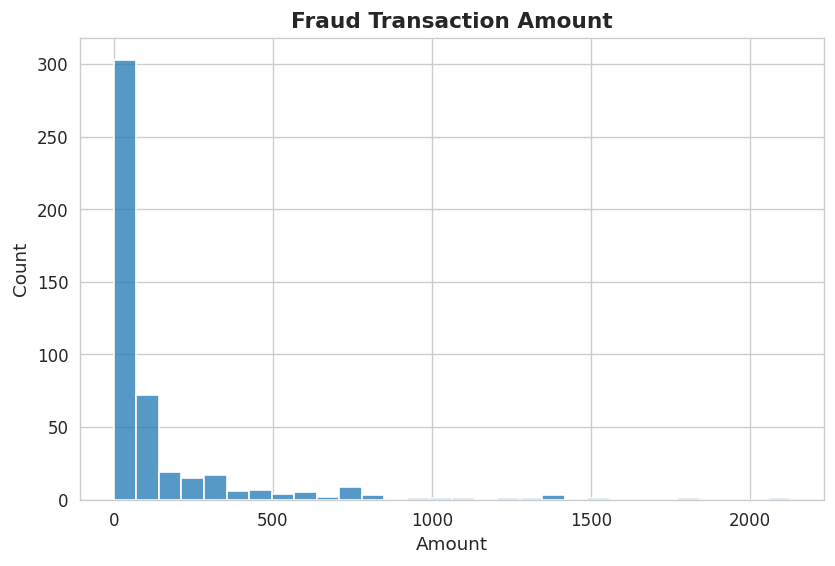

In [ ]:
fraud = df[df['Class'] == 1]

plt.figure(figsize=(8,5))

sns.histplot(fraud['Amount'], bins=30)

plt.title("Fraud Transaction Amount")
plt.show()

# 📈 5.4 Correlation Heatmap

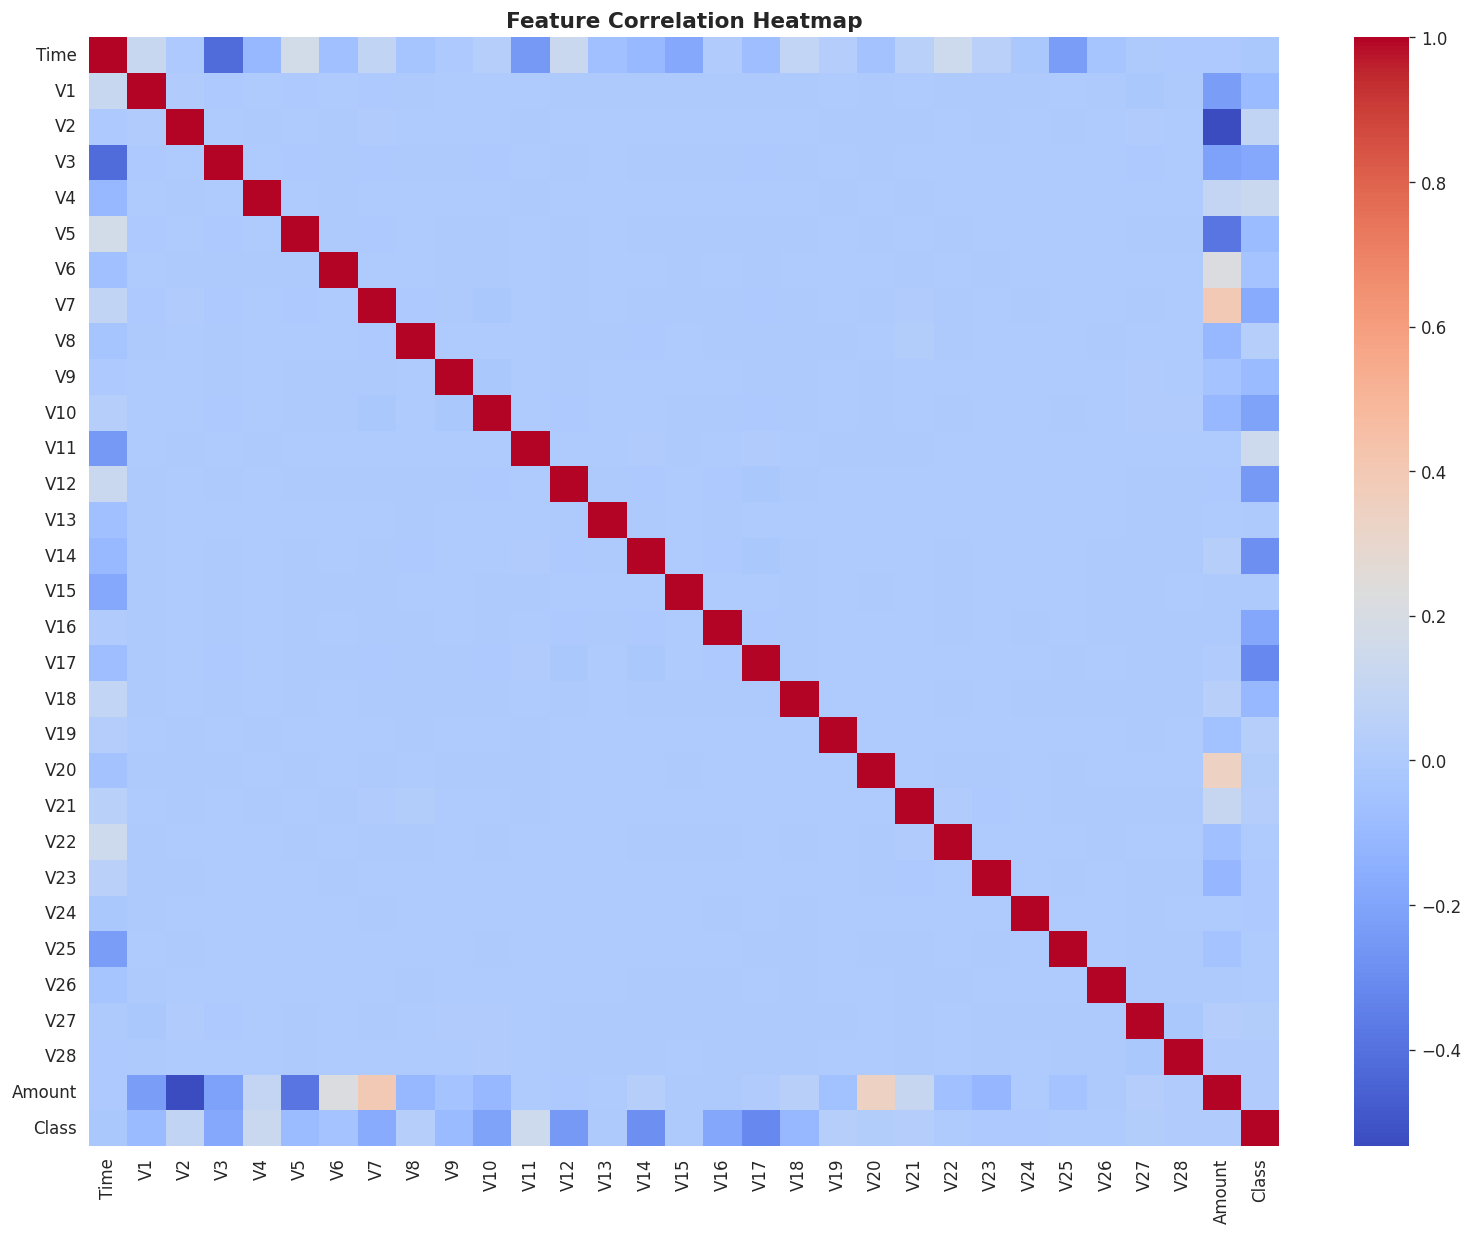

In [ ]:
plt.figure(figsize=(16,12))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

# ⏳ 5.5 Time-Based Transaction Analysis

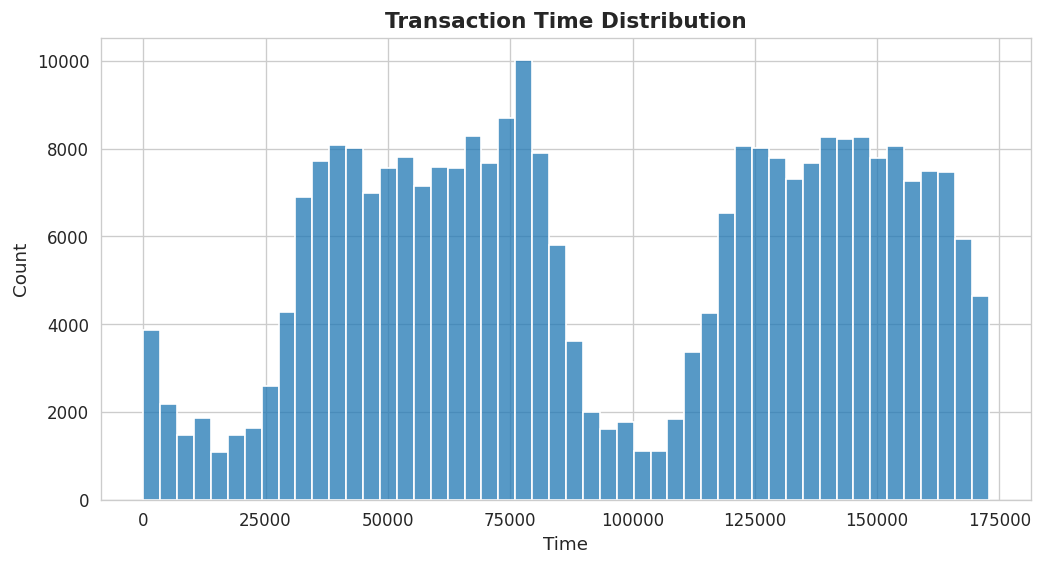

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['Time'], bins=50)

plt.title("Transaction Time Distribution")

plt.show()

# 📉 5.6 Fraud vs Genuine Amount Comparison

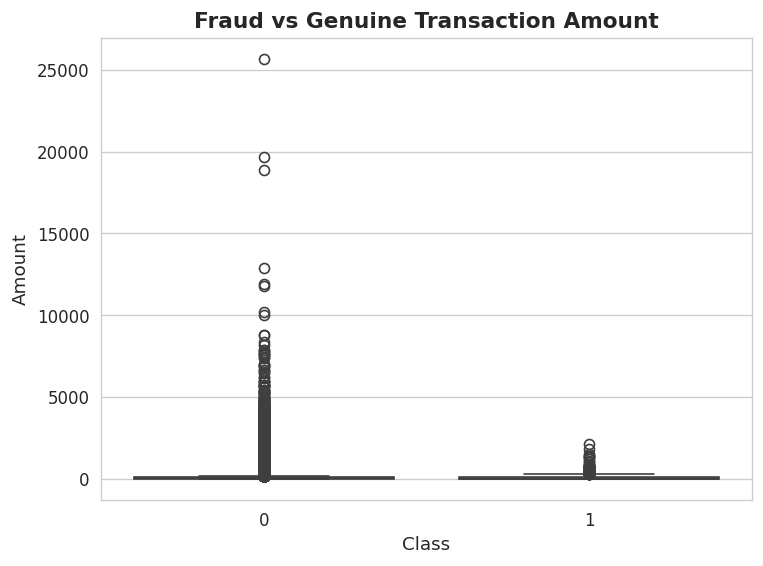

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title("Fraud vs Genuine Transaction Amount")

plt.show()

# Section 6 : Data Preprocessing





## Define Features and Target

In [ ]:
X = df.drop('Class', axis=1)

y = df['Class']

# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Section 7 : Machine Learning Model
🤖 Logistic Regression Model

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)



LogisticRegression()

# Section 8 : Model Prediction

In [ ]:
y_pred = model.predict(X_test)

# 📈 Accuracy Score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9989955239135798


# 📋 Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.73      0.59      0.65        90

    accuracy                           1.00     56746
   macro avg       0.86      0.79      0.82     56746
weighted avg       1.00      1.00      1.00     56746



# 📊 Confusion Matrix

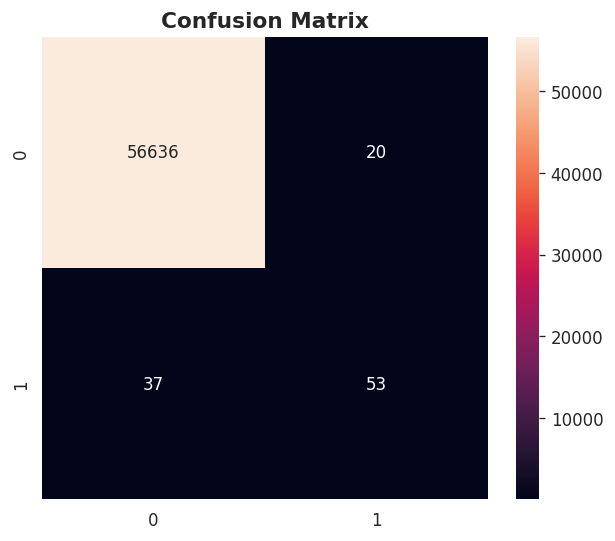

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

# Section 9 : Feature Importance

In [ ]:
importance = abs(model.coef_[0])

features = X.columns

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

feature_df.head(10)

,Feature,Importance
14,V14,1.047426
3,V3,0.810614
2,V2,0.806415
17,V17,0.691101
9,V9,0.615055
8,V8,0.483277
13,V13,0.475029
1,V1,0.422819
16,V16,0.410540
15,V15,0.389599


# 📌 Top Important Features Plot

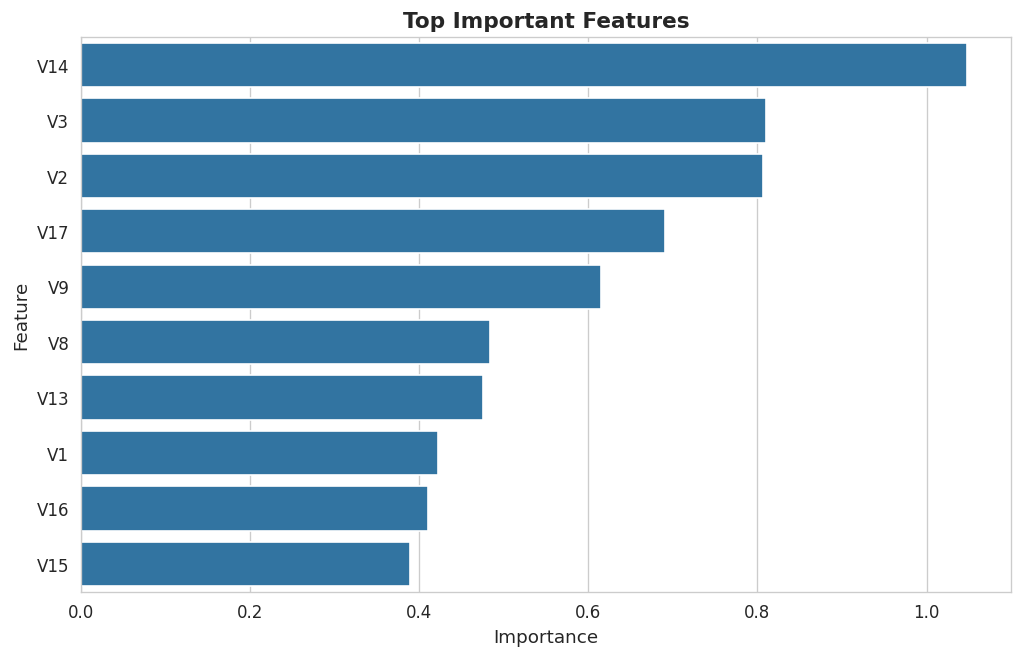

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df.head(10)
)

plt.title("Top Important Features")

plt.show()

# Section 10 : Conclusion

In [ ]:
print("""

Conclusion:

1. Fraud transactions are extremely rare.
2. The dataset is highly imbalanced.
3. Certain transaction patterns strongly indicate fraud.
4. Machine Learning can successfully detect fraud.
5. Features V1-V28 contain critical hidden fraud information.
6. Fraud detection systems are essential for banking security.

""")



Conclusion:

1. Fraud transactions are extremely rare.
2. The dataset is highly imbalanced.
3. Certain transaction patterns strongly indicate fraud.
4. Machine Learning can successfully detect fraud.
5. Features V1-V28 contain critical hidden fraud information.
6. Fraud detection systems are essential for banking security.




# How rare are fraudulent transactions?

In [ ]:
# Count Fraud and Genuine Transactions

fraud_count = df['Class'].value_counts()[1]
genuine_count = df['Class'].value_counts()[0]

total_transactions = len(df)

# Calculate Fraud Percentage
fraud_percentage = (fraud_count / total_transactions) * 100

print("Total Transactions :", total_transactions)
print("Genuine Transactions :", genuine_count)
print("Fraud Transactions :", fraud_count)

print("\nFraud Percentage : {:.4f}%".format(fraud_percentage))

Total Transactions : 283726
Genuine Transactions : 283253
Fraud Transactions : 473

Fraud Percentage : 0.1667%
